In [53]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

In [54]:
df=pd.read_csv('student.csv')

In [55]:
df

,Study_Hours,Attendance,Previous_Mark,Assignment_Score,Sleep_Hours,Absences,Final_Mark
0,2,65,55,60,5,10,58
1,4,78,67,72,6,6,70
2,6,90,82,85,7,2,86
3,8,95,91,94,8,1,94
4,3,70,61,65,5,8,63
5,5,84,75,78,7,4,78
6,7,92,85,88,8,2,89
7,1,55,48,50,4,14,45
8,9,98,94,96,8,0,97
9,4,76,65,70,6,7,68


In [56]:
df.head()

,Study_Hours,Attendance,Previous_Mark,Assignment_Score,Sleep_Hours,Absences,Final_Mark
0,2,65,55,60,5,10,58
1,4,78,67,72,6,6,70
2,6,90,82,85,7,2,86
3,8,95,91,94,8,1,94
4,3,70,61,65,5,8,63


In [57]:
df.tail()

,Study_Hours,Attendance,Previous_Mark,Assignment_Score,Sleep_Hours,Absences,Final_Mark
25,6,86,81,84,7,2,84
26,4,79,68,71,6,7,70
27,8,93,87,90,8,1,91
28,5,83,74,79,6,4,78
29,7,90,86,89,7,2,89


In [58]:
df.describe().round(3)

,Study_Hours,Attendance,Previous_Mark,Assignment_Score,Sleep_Hours,Absences,Final_Mark
count,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,5.467,82.467,75.133,78.500,6.533,4.667,77.533
std,2.389,12.162,13.310,12.851,1.306,3.836,14.642
min,1.000,55.000,48.000,50.000,4.000,0.000,45.000
25%,4.000,75.250,65.500,70.250,6.000,2.000,68.500
50%,5.500,85.000,76.000,79.500,7.000,4.000,79.000
75%,7.000,91.750,85.750,88.750,7.750,7.000,89.000
max,10.000,99.000,96.000,98.000,9.000,14.000,98.000


In [59]:
df.isnull().sum() #no missing values here

,0
Study_Hours,0
Attendance,0
Previous_Mark,0
Assignment_Score,0
Sleep_Hours,0
Absences,0
Final_Mark,0


In [60]:
df.duplicated().sum() #no duplicated values here

np.int64(0)

In [61]:
df.info() #all have integer values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Study_Hours       30 non-null     int64
 1   Attendance        30 non-null     int64
 2   Previous_Mark     30 non-null     int64
 3   Assignment_Score  30 non-null     int64
 4   Sleep_Hours       30 non-null     int64
 5   Absences          30 non-null     int64
 6   Final_Mark        30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


EXPLORATORY DATA ANALYSIS

<Axes: xlabel='Study_Hours', ylabel='Final_Mark'>

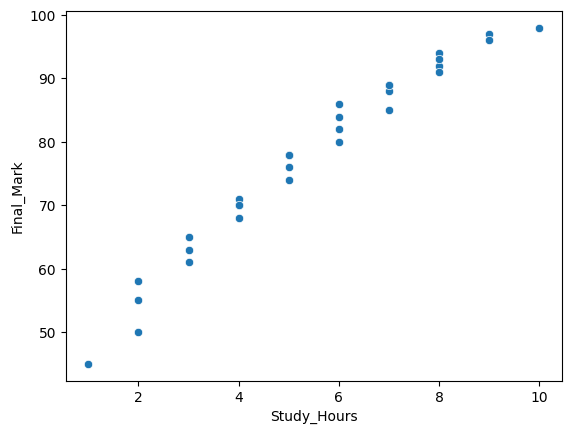

In [62]:
sns.scatterplot(x="Study_Hours",y="Final_Mark",data=df)

<Axes: xlabel='Study_Hours', ylabel='Final_Mark'>

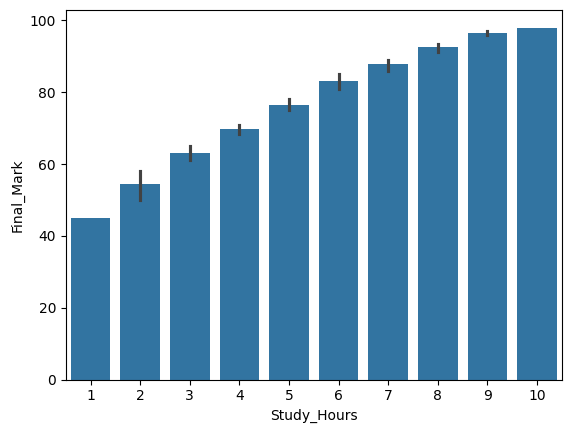

In [63]:
sns.barplot(x="Study_Hours",y="Final_Mark",data=df) #From this we can see that when study hours increase the final marks increase

<Axes: xlabel='Attendance', ylabel='Final_Mark'>

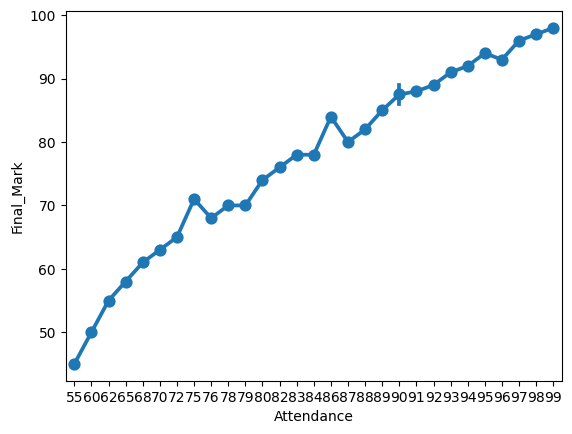

In [64]:
sns.pointplot(x="Attendance",y="Final_Mark",data=df)

<Axes: >

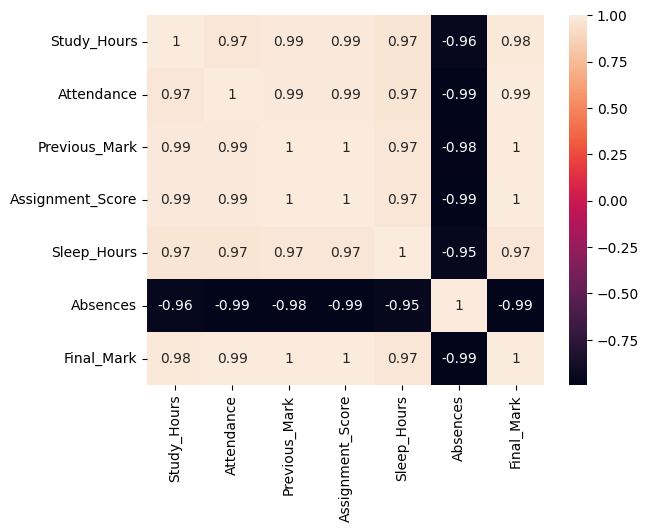

In [65]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Study_Hours', ylabel='Final_Mark'>

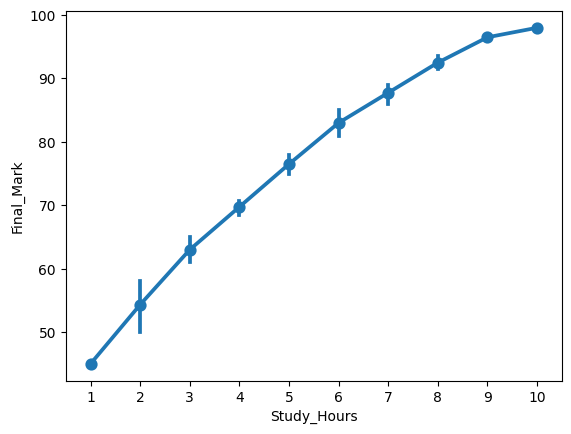

In [66]:
sns.pointplot(x="Study_Hours",y="Final_Mark",data=df)

<Axes: xlabel='Sleep_Hours', ylabel='Final_Mark'>

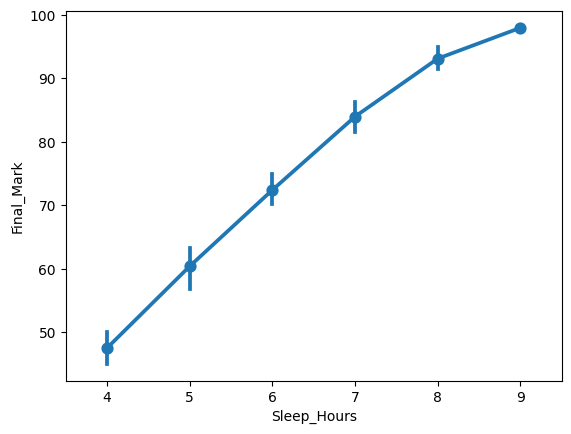

In [67]:
sns.pointplot(x="Sleep_Hours",y="Final_Mark",data=df) #When sleeping hours increases the Mark also increases

TRAINING MODEL

In [68]:
x=df.drop('Final_Mark',axis=1)
y=df['Final_Mark']

In [69]:
x

,Study_Hours,Attendance,Previous_Mark,Assignment_Score,Sleep_Hours,Absences
0,2,65,55,60,5,10
1,4,78,67,72,6,6
2,6,90,82,85,7,2
3,8,95,91,94,8,1
4,3,70,61,65,5,8
5,5,84,75,78,7,4
6,7,92,85,88,8,2
7,1,55,48,50,4,14
8,9,98,94,96,8,0
9,4,76,65,70,6,7


In [70]:
y

,Final_Mark
0,58
1,70
2,86
3,94
4,63
5,78
6,89
7,45
8,97
9,68


In [71]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [72]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [73]:
y_pred=model.predict(x_test)

In [74]:
print(y_pred)

[90.66631749 60.63585711 95.58051247 70.84655089 96.780667   67.99502925]


In [75]:
model.score(x_test,y_test)

0.9996065164171616

In [76]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE",mae)
print("MSE",mse)
print("R2",r2)

MAE 0.2491776318293534
MSE 0.08193202602658205
R2 0.9996065164171616


COMPARING DIFFERENT ML MODELS


Linear Regression


In [77]:
Linear=LinearRegression()
Linear.fit(x_train,y_train)


LinearRegression()

In [78]:
pred=Linear.predict(x_test)

In [79]:
print(pred)

[90.66631749 60.63585711 95.58051247 70.84655089 96.780667   67.99502925]


In [80]:
new_student=pd.DataFrame({
    'Study_Hours':[6],
    'Attendance':[85],
    'Previous_Mark':[75],
    'Assignment_Score':[80],
    'Sleep_Hours':[7],
    'Absences':[2]


})

In [81]:
prediction=Linear.predict(new_student)
print("Predicted Final Score:",prediction[0])

Predicted Final Score: 81.11025964985241


RANDOM FOREST


In [82]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_test,y_test)
rf_pred=rf_model.predict(x_test)


In [83]:
print(rf_pred) #random forest is better because it takes decision by combining many trees(it reduces overfitting)

[92.08 64.03 95.39 69.8  95.82 68.69]


Check for Overfitting
comparing training data and testing data

In [84]:
train_pred=Linear.predict(x_train)
test_pred=Linear.predict(x_test)

r2_train=r2_score(y_train,train_pred)
r2_test=r2_score(y_test,test_pred)

print(r2_train)
print(r2_test)

0.9982678186265436
0.9996065164171616


Training data:0.99
Testing data:0.99

They are good because both training and testing are accurate(No Overfitting)

Now use on new student data


In [85]:
new_student=pd.DataFrame({
    'Study_Hours':[6],
    'Attendance':[85],
    'Previous_Mark':[75],
    'Assignment_Score':[80],
    'Sleep_Hours':[7],
    'Absences':[2]

})

In [86]:
prediction=rf_model.predict(new_student)


In [87]:
print(prediction)

[76.34]


In [88]:
new_student=pd.DataFrame({
    'Study_Hours':[2],
    'Attendance':[79],
    'Previous_Mark':[70],
    'Assignment_Score':[80],
    'Sleep_Hours':[6],
    'Absences':[4]

})

In [89]:
prediction=rf_model.predict(new_student)
print("Predicted Final Score:",prediction[0])

Predicted Final Score: 69.31


Gradient Boosting Model


In [90]:
gb_model=GradientBoostingRegressor(n_estimators=100,
   learning_rate=0.1,
    max_depth=3,
    random_state=42

                                   )

In [91]:
gb_model.fit(x_train,y_train) #Train


GradientBoostingRegressor(random_state=42)

In [92]:
pred=gb_model.predict(x_test)

In [93]:
print(pred)

[90.36746614 63.00039014 94.99177638 68.88793461 96.14427803 69.44391889]


In [94]:
gb_model.score(x_test,y_test) #Here the model is accurate-98%

0.9898376546888523

Checking overfitting by comparing testing data and training data

In [95]:
train_pred=gb_model.predict(x_train)
test_pred=gb_model.predict(x_test)

r2_train=r2_score(y_train,train_pred)
r2_test=r2_score(y_test,test_pred)

print(r2_train)
print(r2_test)

0.9999999988528765
0.9898376546888523


In [96]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE",mae)
print("MSE",mse)
print("R2",r2)


MAE 0.2491776318293534
MSE 0.08193202602658205
R2 0.9996065164171616


In [97]:
new_student=pd.DataFrame({
    'Study_Hours':[2],
    'Attendance':[79],
    'Previous_Mark':[70],
    'Assignment_Score':[80],
    'Sleep_Hours':[6],
    'Absences':[4]}
)

In [98]:
prediction=gb_model.predict(new_student)
print("Final Predicted value:",prediction[0])

Final Predicted value: 73.38442557678181


SO BY COMPARING 3 DIFFERENT MODELS:

1.LINEAR REGRESSION:81%

2.RANDOM FOREST:69%

3.GRADIENT BOOSTING:73%

HERE WE CAN CONCLUDE THAT LINEAR REGRESSION IS THE BEST MODEL WHEN IT COMES TO NUMBER VALUES

ADAPTIVE BOOSTING

In [99]:
model=AdaBoostRegressor(n_estimators=100,
                        learning_rate=0.1,
                        random_state=42
                        )

In [100]:
model.fit(x_train,y_train)


AdaBoostRegressor(learning_rate=0.1, n_estimators=100, random_state=42)

In [101]:
pred=model.predict(x_test)

In [102]:
print(pred)

[90.66666667 63.         93.5        70.         94.         70.        ]


In [103]:
MAE=mean_absolute_error(y_test,pred)
MSE=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)

print("MAE:",MAE)
print("MSE:",MSE)
print("RSME:",rmse)
print("R2:",r2)

MAE: 1.8055555555555547
MSE: 4.060185185185184
RSME: 0.28623770895285977
R2: 0.9805007114905727


XGBOOST


In [104]:
model=XGBRegressor(n_estimators=100,learning_rate=0.3,max_depth=3,random_state=42)

In [105]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [107]:
y_pred=model.predict(x_test)

In [108]:
print(y_pred)

[91.99877  62.99726  94.05572  69.999825 94.05572  69.999825]


In [117]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RSME=np.sqrt(y_test,y_pred)
R2=r2_score(y_test,y_pred)

print("MEAN ABSOLUTE ERROR:",MAE)

print("MEAN SQUARED RROR:",MSE)

print("RSME:",RSME)

MEAN ABSOLUTE ERROR: 71.72186279296875
MEAN SQUARED RROR: 5329.51611328125
RSME: 27    9.539392
15    7.810250
23    9.797959
17    8.426149
8     9.848858
9     8.246211
Name: Final_Mark, dtype: float32


In [118]:
new_student=pd.DataFrame({
    'Study_Hours':[2],
    'Attendance':[79],
    'Previous_Mark':[70],
    'Assignment_Score':[80],
    'Sleep_Hours':[6],
    'Absences':[4]

})


In [119]:
prediction=model.predict(new_student)
print("Final Predicted Score",prediction[0])

Final Predicted Score 61.591183
